In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Female,21,16,81
2,3,Female,20,17,6
3,4,Male,23,18,77
4,5,Female,31,20,40


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Shape: (10, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicates: 0


In [4]:
df = df.drop_duplicates()
df = df.dropna()

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Female,21,16,81
2,3,Female,20,17,6
3,4,Male,23,18,77
4,5,Female,31,20,40


In [5]:
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,16,81
2,20,17,6
3,23,18,77
4,31,20,40


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.13243791, -0.9998124 , -0.3952707 ],
       [-0.83442794, -0.9313321 ,  1.18581211],
       [-0.98343293, -0.8628518 , -1.63755006],
       [-0.53641796, -0.7943715 ,  1.03523279],
       [ 0.65562195, -0.65741089, -0.35762587]])

C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

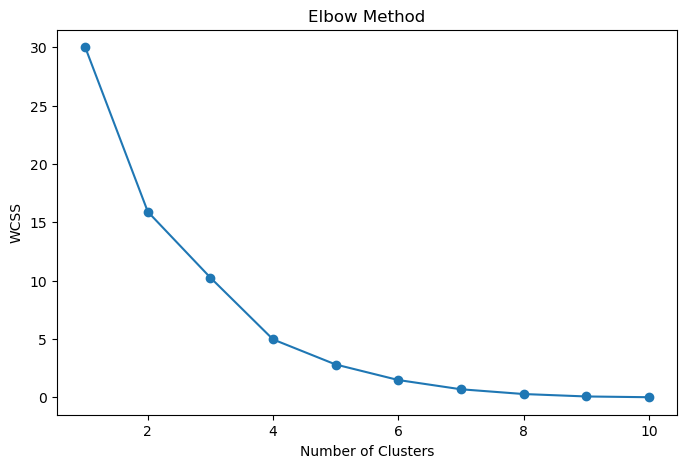

In [7]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

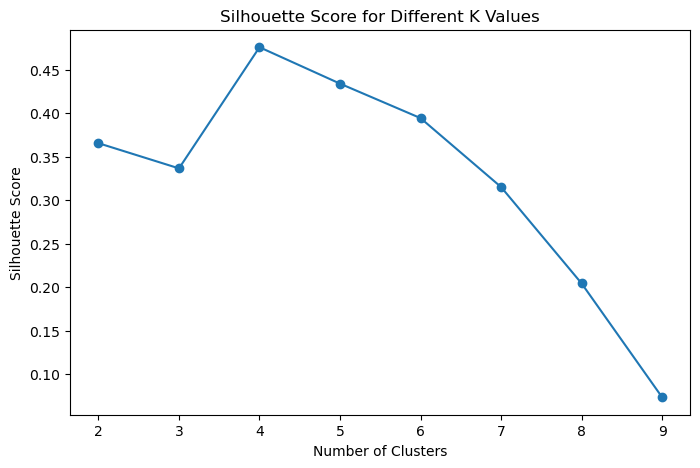

In [9]:
silhouette_scores = []

# Number of samples
n_samples = len(X_scaled)

for k in range(2, min(10, n_samples - 1) + 1):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# K values used
k_values = range(2, min(10, n_samples - 1) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

In [10]:
best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("Best Number of Clusters:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best Number of Clusters: 4
Best Silhouette Score: 0.4758720885049607


In [11]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Female,21,16,81,3
2,3,Female,20,17,6,0
3,4,Male,23,18,77,3
4,5,Female,31,20,40,2


In [12]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    2
1    2
2    3
3    3
Name: count, dtype: int64


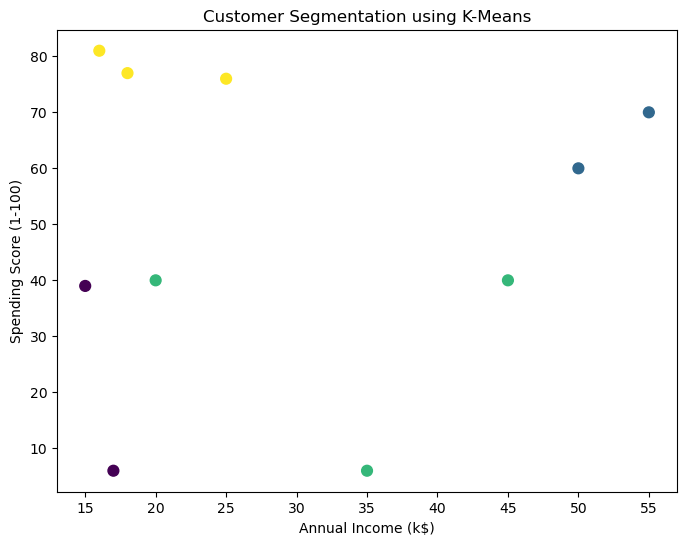

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [14]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,19.500000,16.000000,22.500000
1,27.500000,52.500000,65.000000
2,35.333333,33.333333,28.666667
3,22.000000,19.666667,78.000000


In [15]:
final_score = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print("Final Silhouette Score:", final_score)

Final Silhouette Score: 0.4758720885049607


In [16]:
# Get cluster centroids in original scale

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroid_df = pd.DataFrame(
    centroids,
    columns=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

centroid_df.index.name = "Cluster"

centroid_df

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,19.500000,16.000000,22.500000
1,27.500000,52.500000,65.000000
2,35.333333,33.333333,28.666667
3,22.000000,19.666667,78.000000


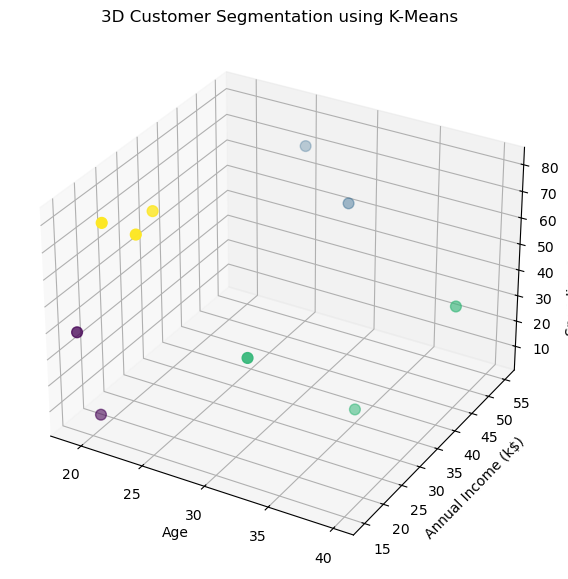

In [17]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["Age"],
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")

ax.set_title("3D Customer Segmentation using K-Means")

plt.show()

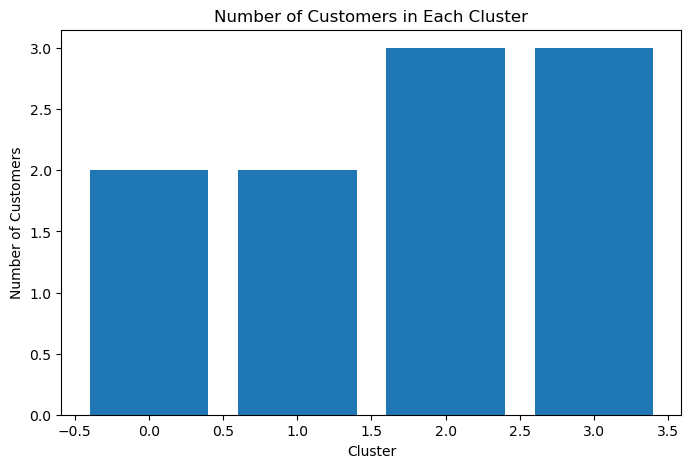

In [18]:
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index,
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")

plt.show()

In [20]:
comparison = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_scores
})

comparison

,K,Silhouette Score
0,2,0.365613
1,3,0.336665
2,4,0.475872
3,5,0.434029
4,6,0.394425
5,7,0.315269
6,8,0.204556
7,9,0.073746


In [21]:
for cluster in sorted(df["Cluster"].unique()):
    
    print("\n" + "=" * 50)
    print("CLUSTER", cluster)
    print("=" * 50)
    
    cluster_data = df[df["Cluster"] == cluster]
    
    print("Number of Customers:", len(cluster_data))
    
    print("\nAverage Characteristics:")
    print(cluster_data[[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]].mean())


CLUSTER 0
Number of Customers: 2

Average Characteristics:
Age                       19.5
Annual Income (k$)        16.0
Spending Score (1-100)    22.5
dtype: float64

CLUSTER 1
Number of Customers: 2

Average Characteristics:
Age                       27.5
Annual Income (k$)        52.5
Spending Score (1-100)    65.0
dtype: float64

CLUSTER 2
Number of Customers: 3

Average Characteristics:
Age                       35.333333
Annual Income (k$)        33.333333
Spending Score (1-100)    28.666667
dtype: float64

CLUSTER 3
Number of Customers: 3

Average Characteristics:
Age                       22.000000
Annual Income (k$)        19.666667
Spending Score (1-100)    78.000000
dtype: float64


In [22]:
df.to_csv(
    "customer_segmentation_result.csv",
    index=False
)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!
